# Today's classification next to the new one
Both verdicts are put on the same occurrences, so the dots never move between panels: only their colour, which is the verdict each classification gives them. Three-item rules only. Nothing is filtered out by either classification, so the rules each one drops are visible too.

In [1]:
import os
import sys

sys.path[:0] = [os.path.abspath("scripts"), os.path.abspath(".."), os.path.abspath("../differential_rules/scripts")]
import complex_investigation as ci
import classification_comparison as cc

In [2]:
CONFIG = ci.Config(
    max_items=3, support=0.01, expected_support=0.01, confidence=0.5,
    min_cells=20, mining_fdr=0.05,
)
PREFIX = "comparison"
# How many places along the kept share to take examples from, and how wide a band
# around each one counts as that place.
ANT_PLACES, CON_PLACES, BAND = 3, 4, 0.15
# What a rule's improvement over its shorter rule is read on.
ANT_COMPLEX_METRIC = "Lift"
GAIN = {"ant-complex": ANT_COMPLEX_METRIC, "con-complex": "Conviction"}

One dot is one stored rule in one field, kept as mined: the mining center is not averaged away, because both classifications judge each arrangement on its own. Left to right is the rule's own support; bottom to top is how much it improves on the strongest shorter rule measured in that same field, counted in the rule's own direction: lift for the antecedent rules, conviction for the consequent ones, which is the value each new verdict is decided on. A rule with no measured shorter rule has no gain to show and is left out, with its count in the title.

In [3]:
cells, metadata, rules = cc.load(CONFIG)
ROWS = cc.dots(rules, CONFIG, GAIN)
ROWS.groupby(["Rule_Type", "Kind"]).Complex_Class_2.value_counts().unstack(fill_value=0)

Dropped 21 FOVs: Control_S
Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71
Read results_CN_pairwise.csv + results_CN_complex.csv
{'max_items': 3, 'min_cells': 20, 'mining_fdr': 0.05, 'support': 0.01, 'confidence': 0.5, 'expected_support': 0.01, 'score': 'Clinical score', 'min_fovs': 5, 'min_patients': 3, 'min_group_fovs': 10, 'visible_gap': 0.15, 'attraction_lift_gap': 0.3, 'avoidance_lift_gap': 0.15, 'permutations': 4999, 'top_n': 8}
145,687 stored center-specific occurrences; distinct cell types only
Mining settings: {'settings': {'weighting': 'binary', 'method': 'CN', 'radius': 25.0, 'min_support': 0.01, 'min_lift': 1.2, 'max_items_per_rule': 4, 'bandwidth': 15.0, 'k_neighbors': None, 'min_cells_per_patch': 2, 'max_one_type_share': 0.9, 'min_patches': 15, 'strong_confidence': 0.9, 'min_support_when_strong': 0.005, 'min_confidence': 0.5, 'min_leverage': 0.0005, 'min_conviction': 1.3, 'include_avoidance_rules': True, 'avoidance_max_lift': 0.8, 'avoidance_max_leverage': None

Complex_Class_2       no shorter  not improving  simpler_are_noise  \
Rule_Type   Kind                                                     
ant-complex attracts        9117           9558                791   
            avoids          3103          11450                319   
con-complex attracts         793           2597                457   
            avoids           816          12954                134   

Complex_Class_2       stronger than shorter  
Rule_Type   Kind                             
ant-complex attracts                   1786  
            avoids                     3133  
con-complex attracts                    743  
            avoids                      668

## 1. Multiple antecedents
Two cell types on the left of the arrow, one on the right. Today a rule is kept when its lift beats the strongest shorter rule by a margin; the new verdict asks whether its confidence improves on the shorter rule by more than chance allows.

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_ant-complex_attracts.pdf


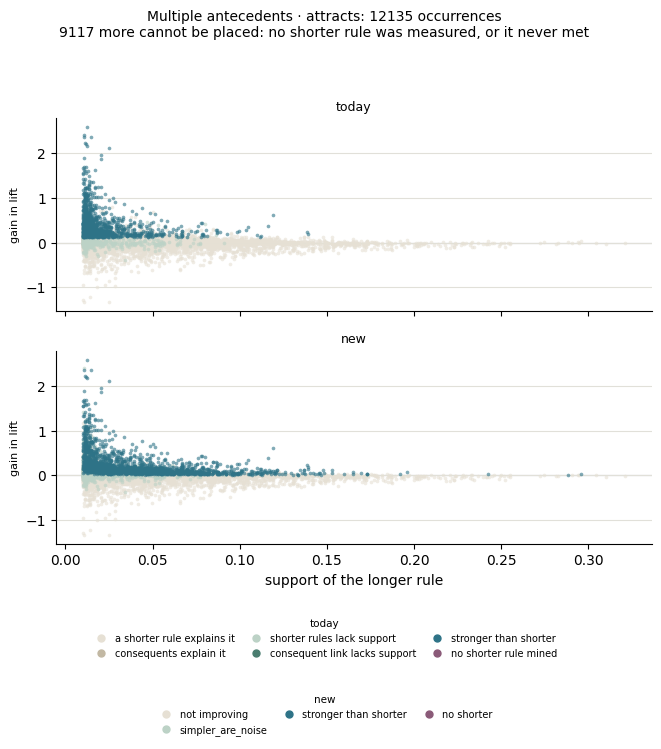

In [4]:
cc.show(ROWS, "ant-complex", "attracts", PREFIX, GAIN)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_ant-complex_avoids.pdf


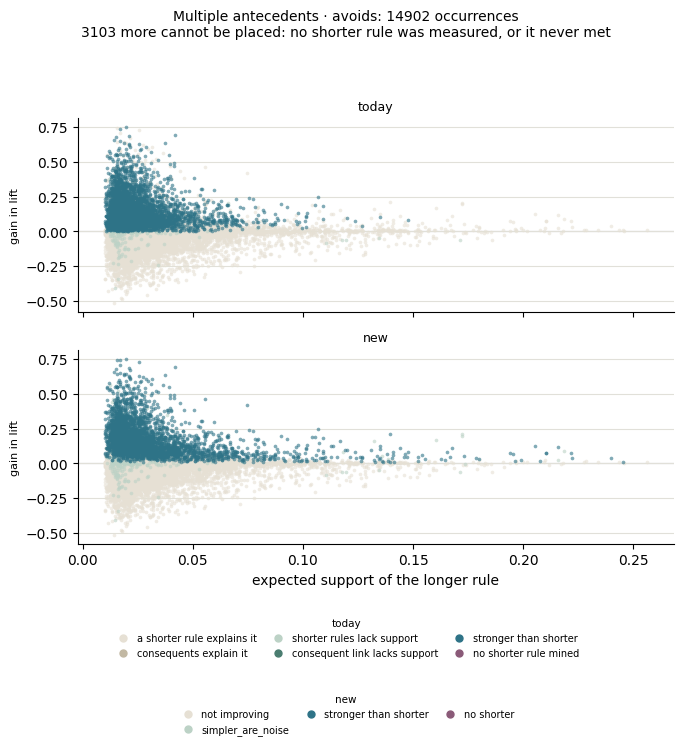

In [5]:
cc.show(ROWS, "ant-complex", "avoids", PREFIX, GAIN)

### Gain of conviction x loose support ratio

The same dots against what the longer rule pays for its extra item: the share of the shorter rule's support it still holds. One means it loses nothing. The ringed rules are drawn as fields below. They are taken at even steps along the axis, from the rules the new verdict keeps: the strongest gain around each step, and for the antecedent rules the flattest one as well. Each field shows the whole field, the rule's cells, and the shorter rule it was judged against.

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_ant-complex_attracts_kept.pdf


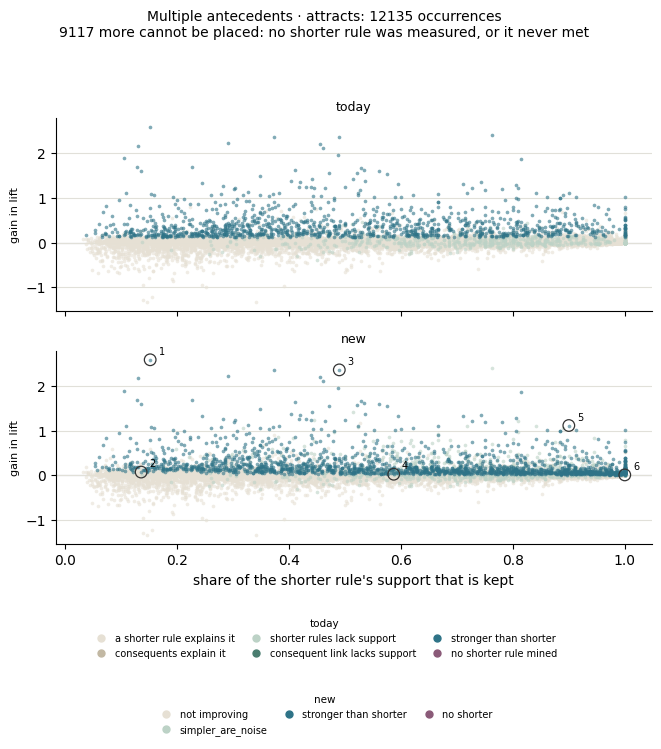

In [6]:
ANT_ATTRACTS = cc.examples(ROWS, "ant-complex", "attracts", ANT_PLACES, BAND)
cc.show(ROWS, "ant-complex", "attracts", PREFIX, GAIN,
        across="kept_share", mark=ANT_ATTRACTS)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_ant-complex_attracts_1_fovs.pdf


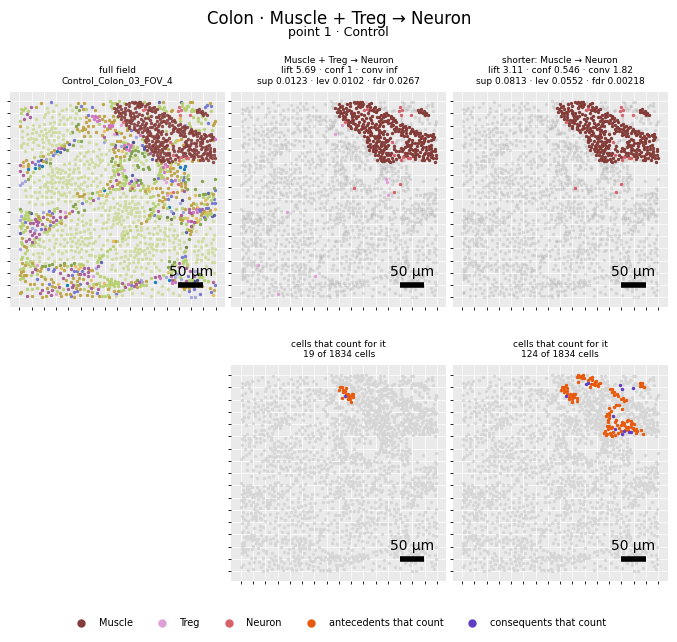

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_ant-complex_attracts_2_fovs.pdf


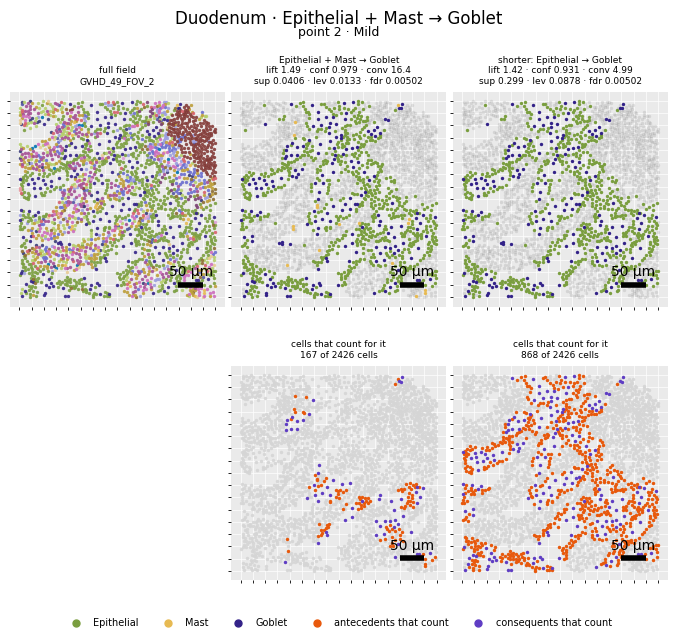

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_ant-complex_attracts_3_fovs.pdf


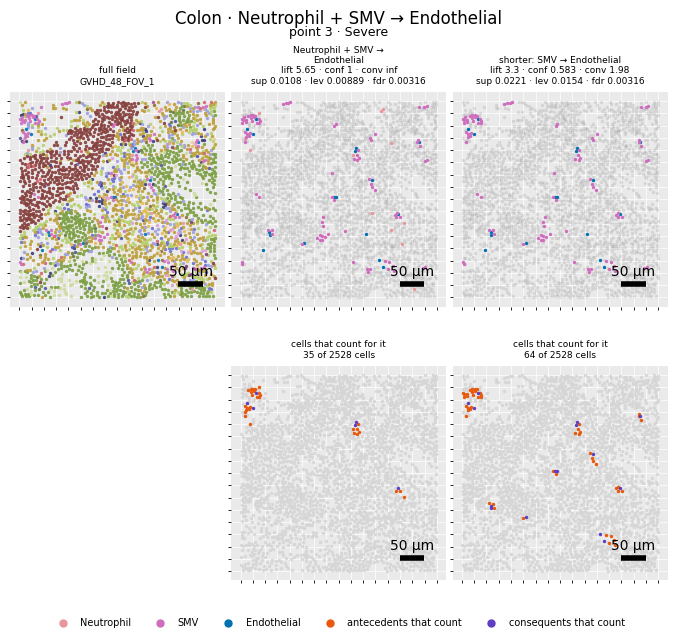

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_ant-complex_attracts_4_fovs.pdf


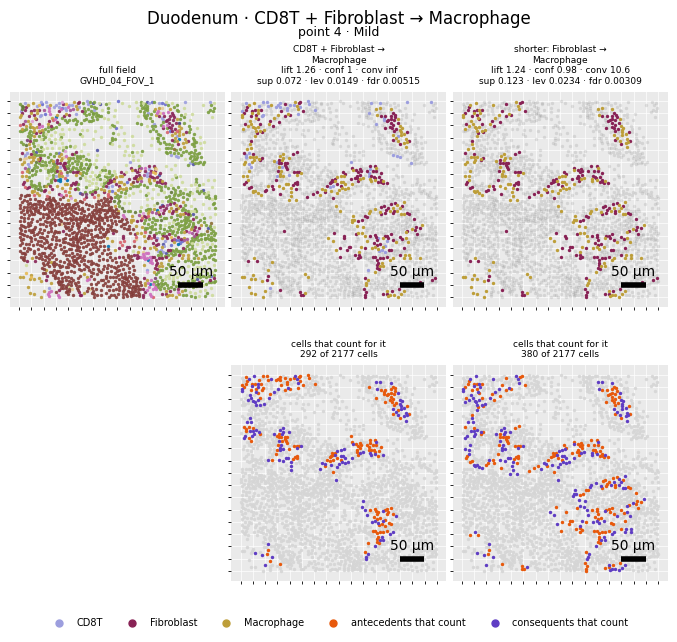

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_ant-complex_attracts_5_fovs.pdf


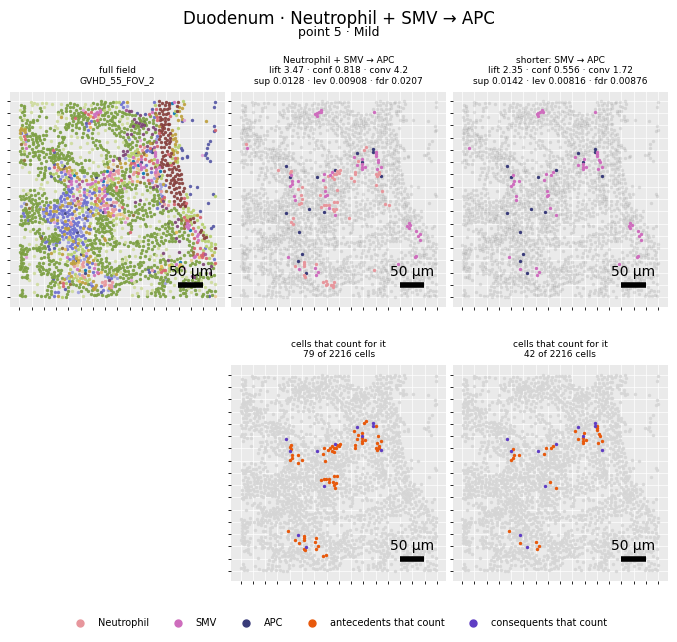

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_ant-complex_attracts_6_fovs.pdf


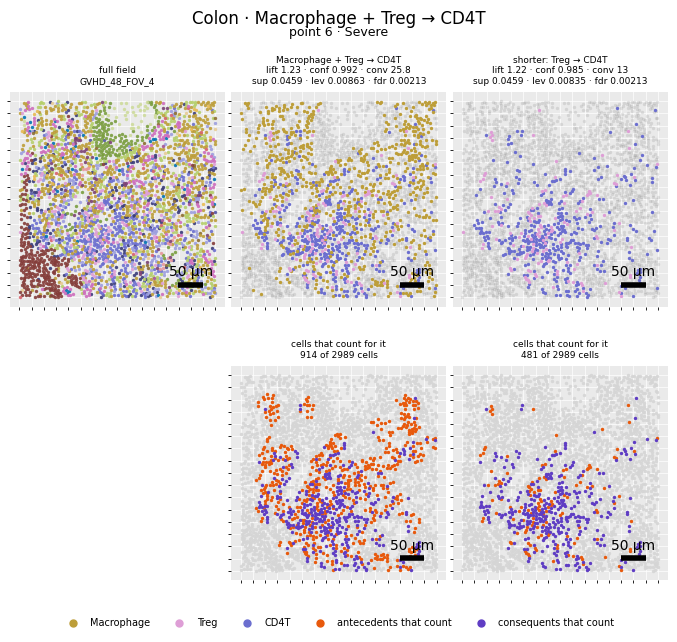

In [7]:
for index in ANT_ATTRACTS.index:
    cc.show_rule(ANT_ATTRACTS, index, ROWS, rules, cells, metadata, CONFIG, PREFIX)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_ant-complex_avoids_kept.pdf


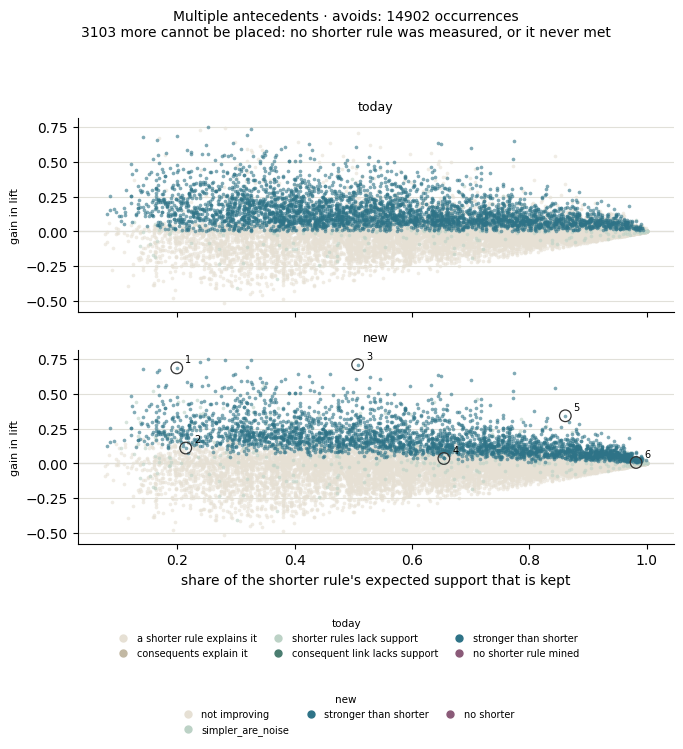

In [8]:
ANT_AVOIDS = cc.examples(ROWS, "ant-complex", "avoids", ANT_PLACES, BAND)
cc.show(ROWS, "ant-complex", "avoids", PREFIX, GAIN,
        across="kept_share", mark=ANT_AVOIDS)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_ant-complex_avoids_1_fovs.pdf


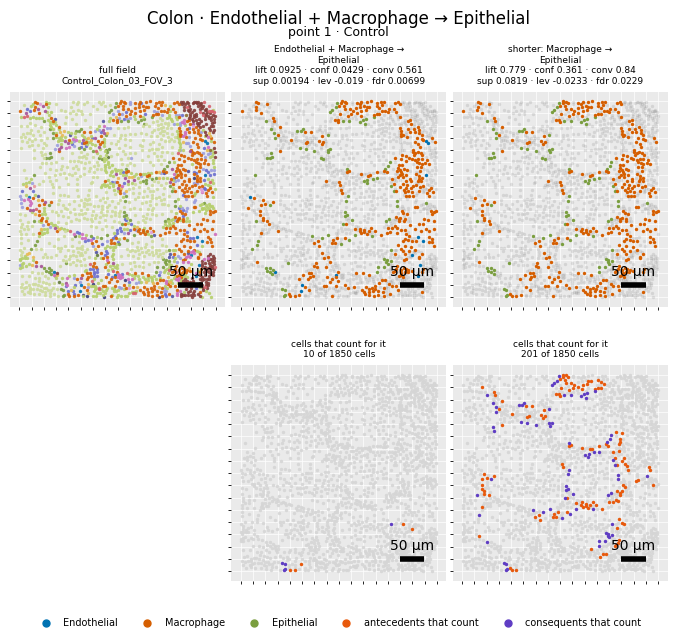

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_ant-complex_avoids_2_fovs.pdf


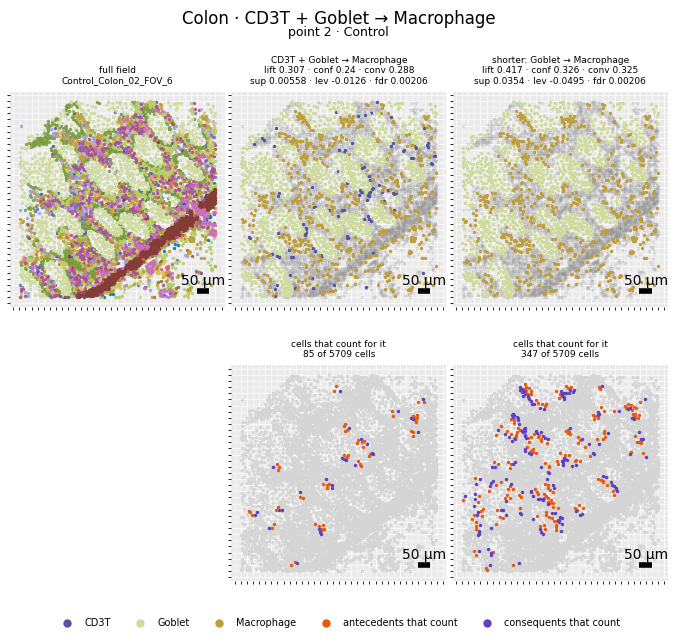

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_ant-complex_avoids_3_fovs.pdf


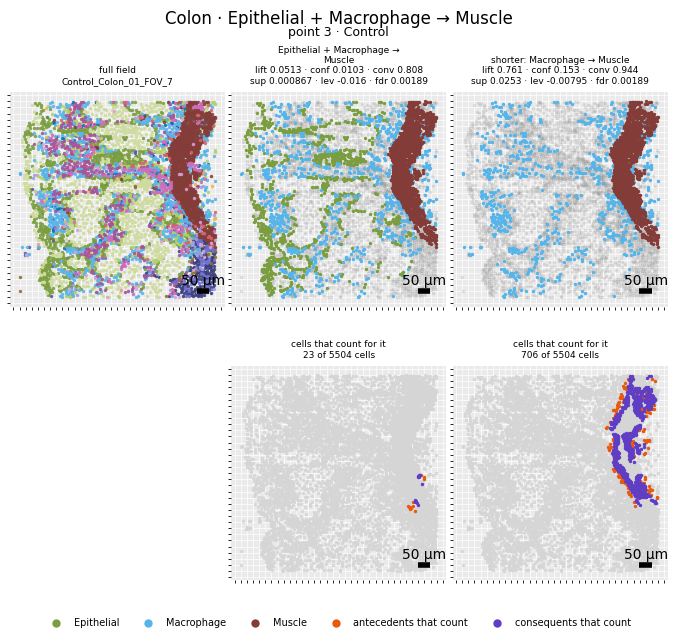

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_ant-complex_avoids_4_fovs.pdf


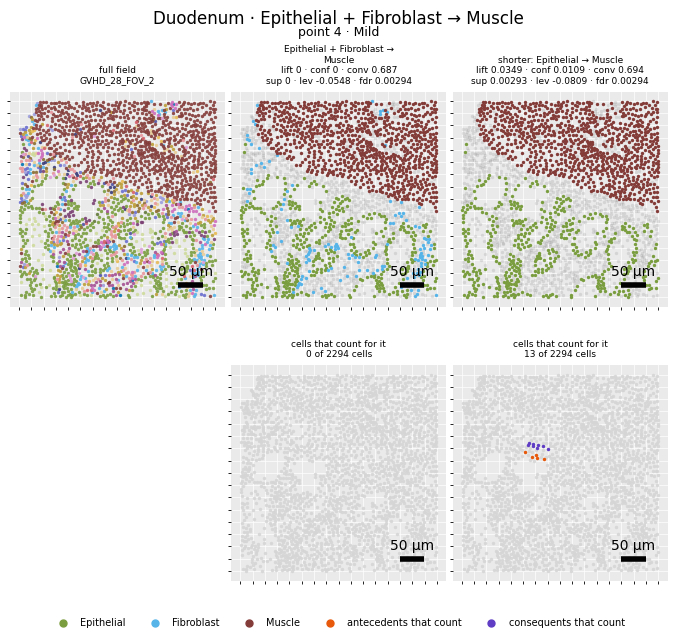

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_ant-complex_avoids_5_fovs.pdf


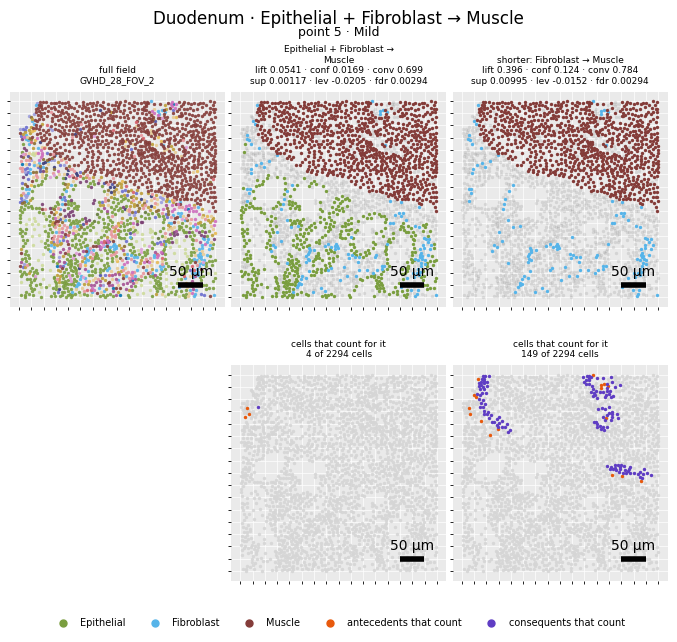

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_ant-complex_avoids_6_fovs.pdf


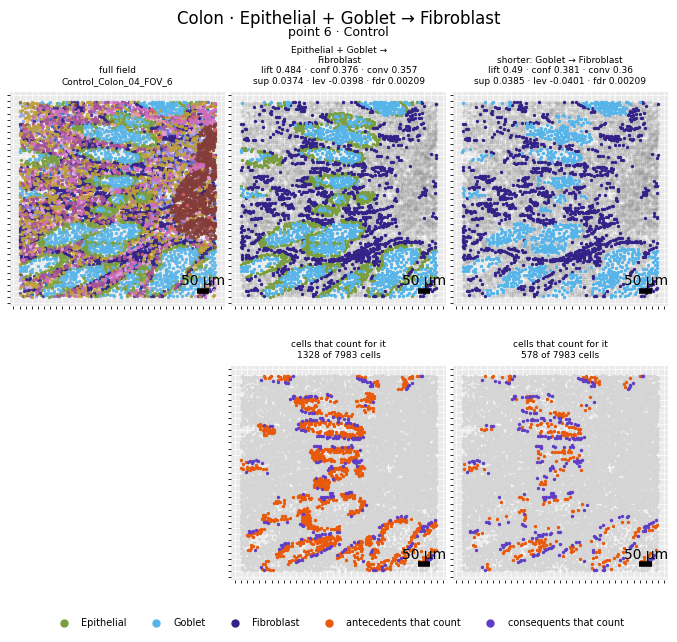

In [9]:
for index in ANT_AVOIDS.index:
    cc.show_rule(ANT_AVOIDS, index, ROWS, rules, cells, metadata, CONFIG, PREFIX)

## 2. Multiple consequents
One cell type on the left of the arrow, two on the right. The new verdict reads conviction instead of lift, so a rule can rise on this axis and still be dropped, or the other way round.

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_con-complex_attracts.pdf


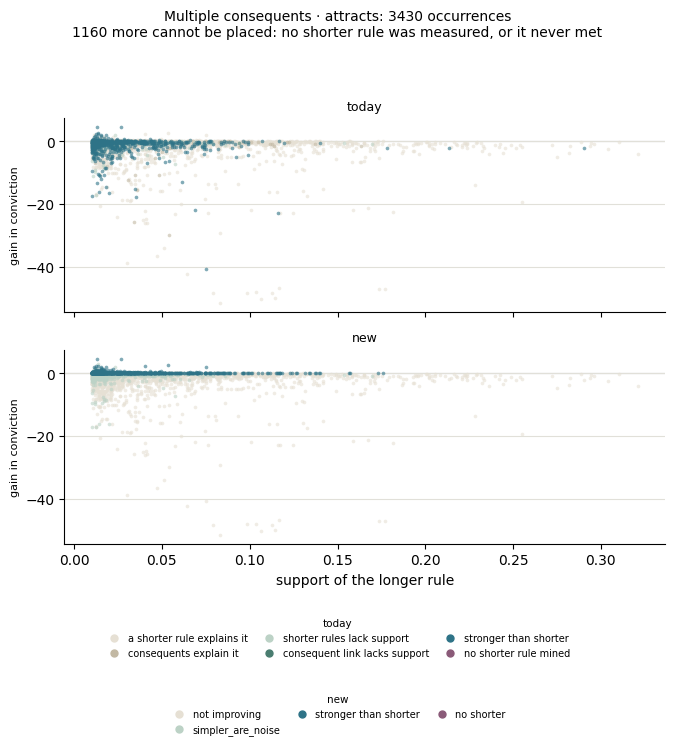

In [10]:
cc.show(ROWS, "con-complex", "attracts", PREFIX, GAIN)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_con-complex_avoids.pdf


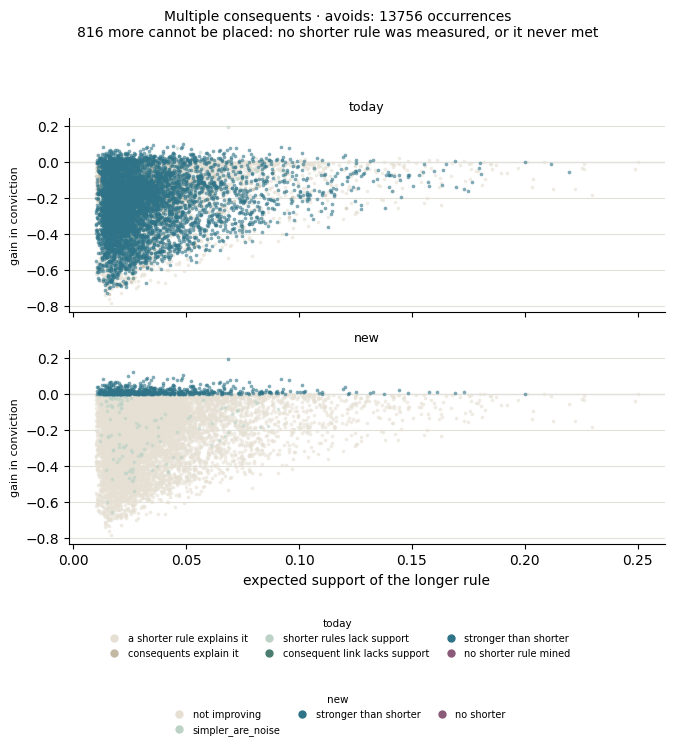

In [11]:
cc.show(ROWS, "con-complex", "avoids", PREFIX, GAIN)

### Gain of conviction x loose support ratio

The same dots against what the longer rule pays for its extra item: the share of the shorter rule's support it still holds. One means it loses nothing. The ringed rules are drawn as fields below. They are taken at even steps along the axis, from the rules the new verdict keeps: the strongest gain around each step, and for the antecedent rules the flattest one as well. Each field shows the whole field, the rule's cells, and the shorter rule it was judged against.

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_con-complex_attracts_kept.pdf


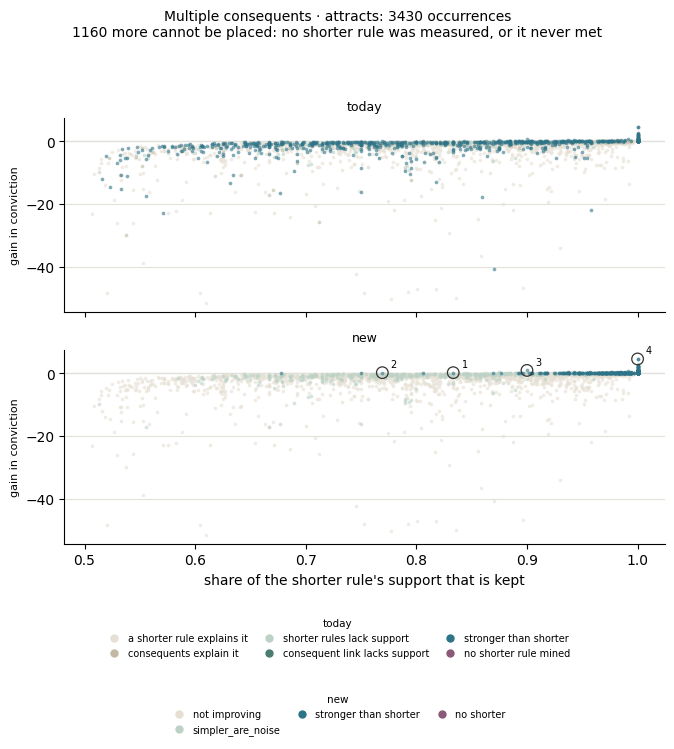

In [12]:
CON_ATTRACTS = cc.examples(ROWS, "con-complex", "attracts", CON_PLACES, BAND,
                     flattest_too=False)
cc.show(ROWS, "con-complex", "attracts", PREFIX, GAIN,
        across="kept_share", mark=CON_ATTRACTS)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_con-complex_attracts_1_fovs.pdf


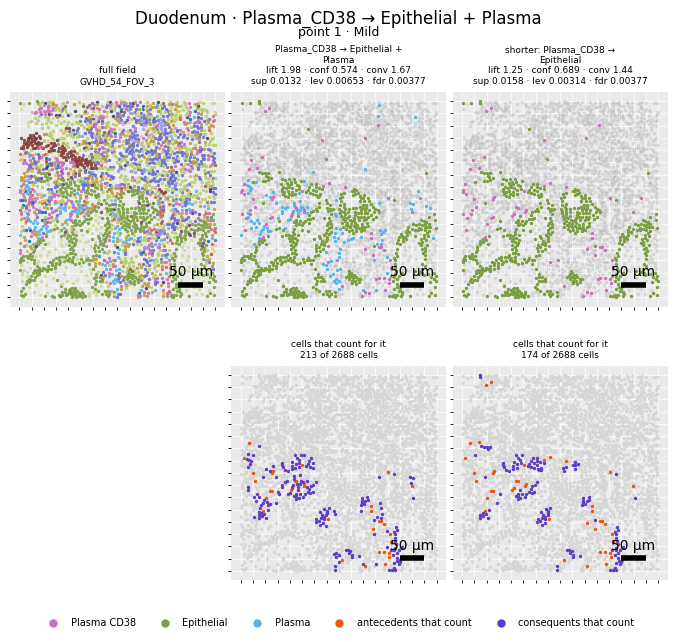

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_con-complex_attracts_2_fovs.pdf


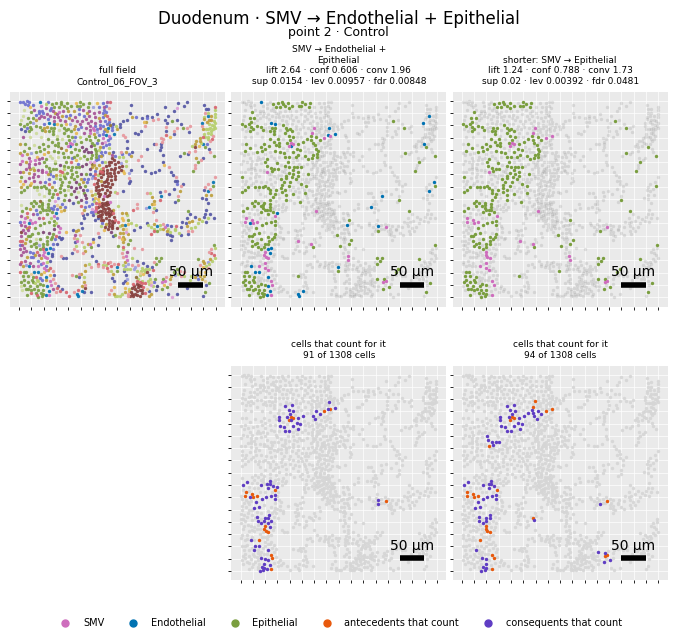

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_con-complex_attracts_3_fovs.pdf


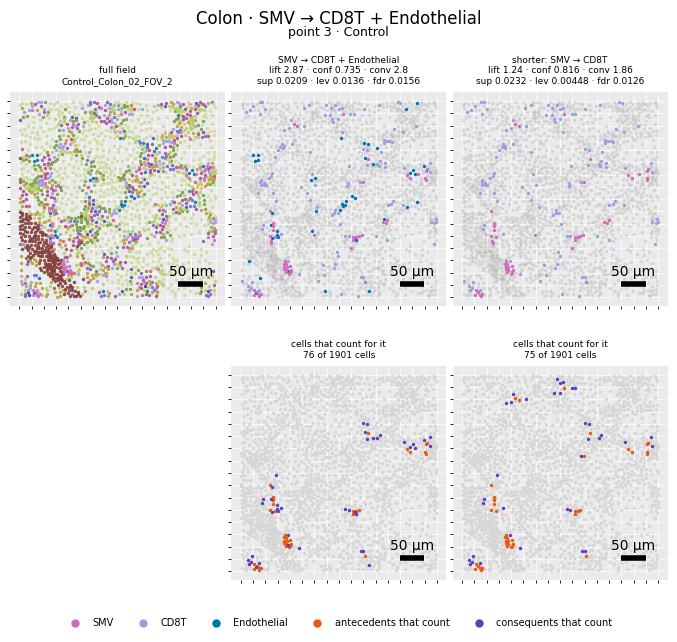

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_con-complex_attracts_4_fovs.pdf


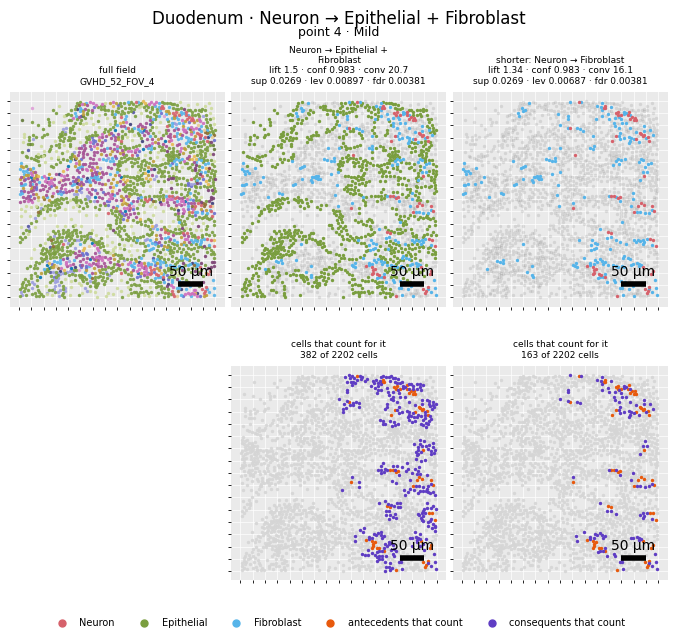

In [13]:
for index in CON_ATTRACTS.index:
    cc.show_rule(CON_ATTRACTS, index, ROWS, rules, cells, metadata, CONFIG, PREFIX)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_con-complex_avoids_kept.pdf


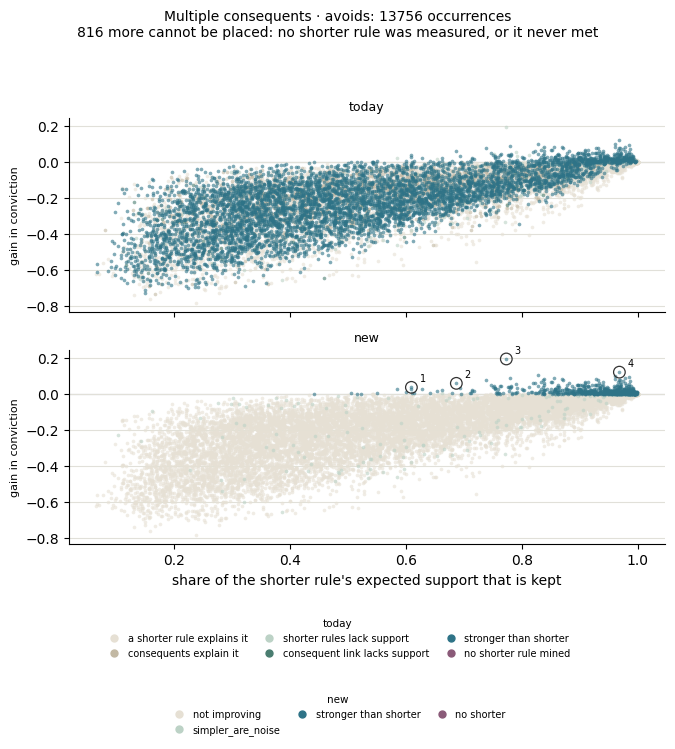

In [14]:
CON_AVOIDS = cc.examples(ROWS, "con-complex", "avoids", CON_PLACES, BAND,
                     flattest_too=False)
cc.show(ROWS, "con-complex", "avoids", PREFIX, GAIN,
        across="kept_share", mark=CON_AVOIDS)

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_con-complex_avoids_1_fovs.pdf


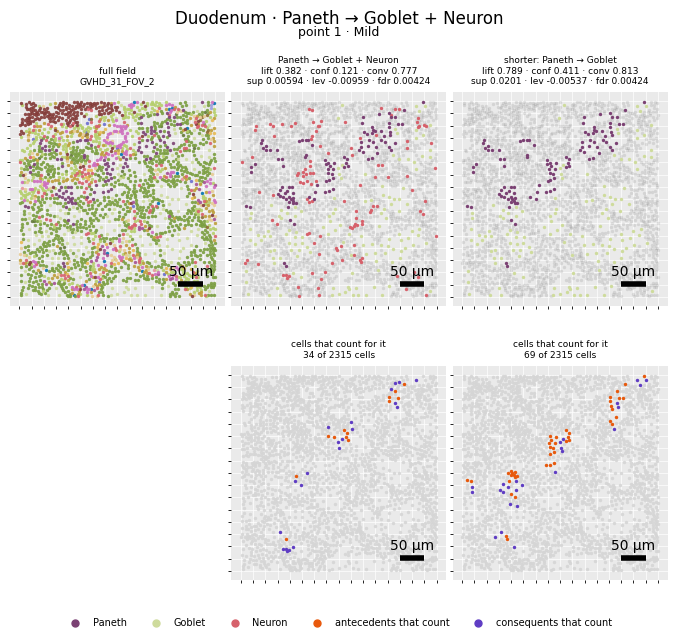

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_con-complex_avoids_2_fovs.pdf


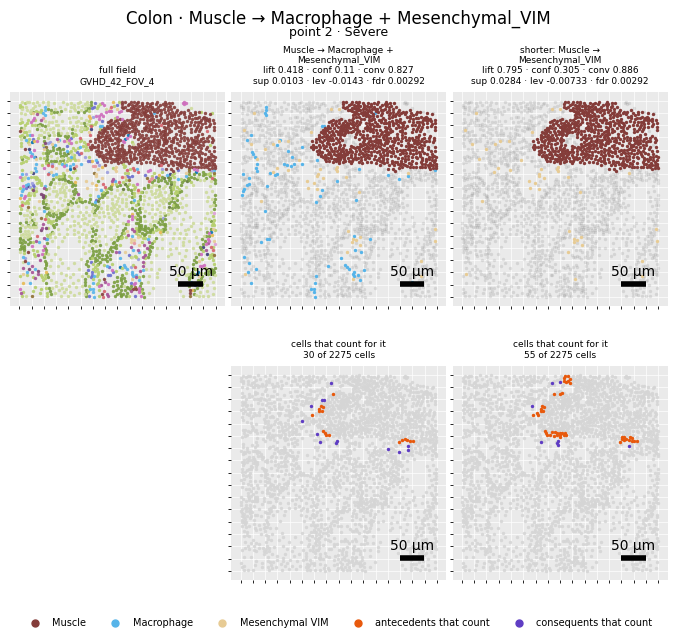

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_con-complex_avoids_3_fovs.pdf


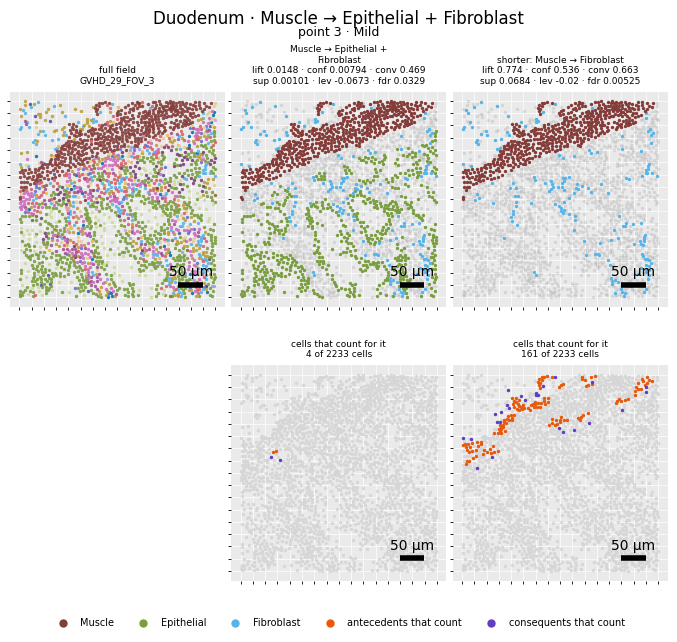

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\comparison_con-complex_avoids_4_fovs.pdf


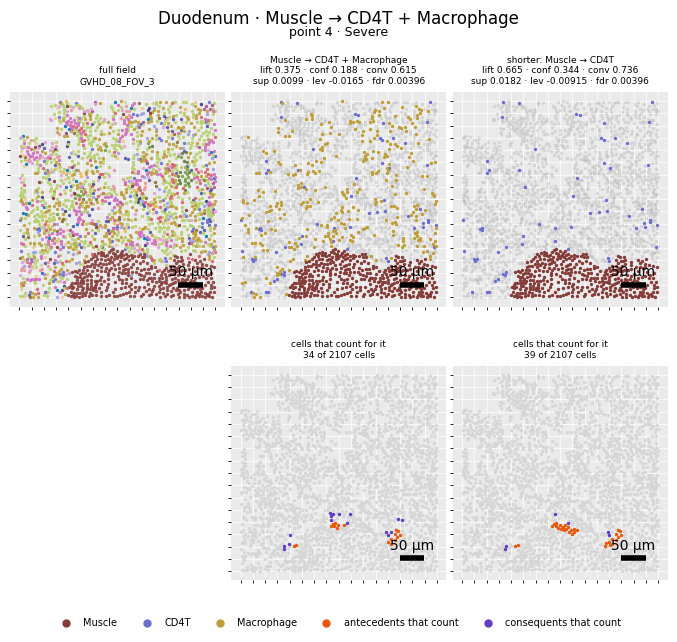

In [15]:
for index in CON_AVOIDS.index:
    cc.show_rule(CON_AVOIDS, index, ROWS, rules, cells, metadata, CONFIG, PREFIX)